# 2D analysis

Run a polar sweep over the visible foil sections and plot the raw numbers —
lift curve, drag polar, and chordwise pressure distributions.

In [ ]:
from pytakeoff import TakeoffClient

API_KEY = "tk_xxxxxxxx_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # get a key in the GUI (Account -> API Keys) or run: python -m pytakeoff


client = TakeoffClient(api_key=API_KEY)
print(f"Connected to {client.base_url} as {client.username}")

project = client.projects.current() or client.projects.open(client.projects.list()[0]["name"])
project

Connected to http://localhost:8000 as nicopeis


Project('260622_Test_beach_toy')

## Configure and run the sweep

In [2]:
import matplotlib.pyplot as plt

analysis = project.analysis_2d(
    alpha_range=[-5, 0, 2, 4, 6, 8, 10],
    reynolds_million=1.0,
    flap_lock=True,       # plain alpha sweep
    solver=["NN"],
    fluid="water",
)
result = analysis.run()
result["variables"][:10]

['alpha',
 'Cl',
 'Cd',
 'Cdp',
 'Cm',
 'Cl_Cd',
 'Cdf',
 'top_xtr',
 'bot_xtr',
 'flap_angle']

## Lift curve and drag polar

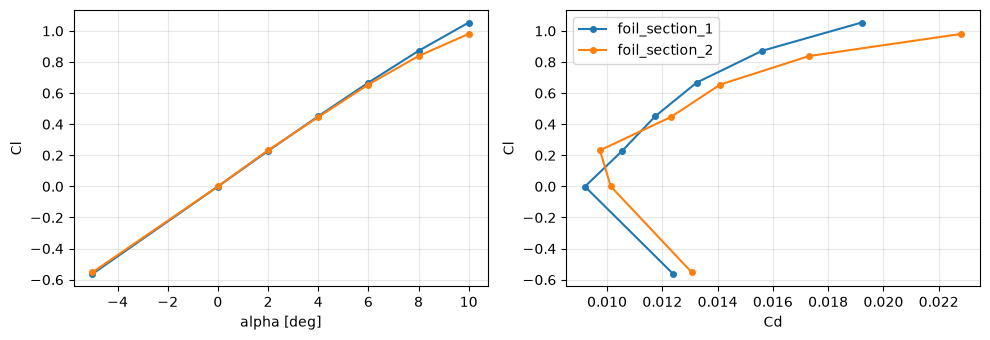

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for s in result["sections"]:
    d = s["data"]
    ax1.plot(d["alpha"], d["Cl"], "o-", ms=4, label=s["section"])
    ax2.plot(d["Cd"], d["Cl"], "o-", ms=4, label=s["section"])
ax1.set_xlabel("alpha [deg]"); ax1.set_ylabel("Cl"); ax1.grid(alpha=0.3)
ax2.set_xlabel("Cd"); ax2.set_ylabel("Cl"); ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()

## Glide ratio

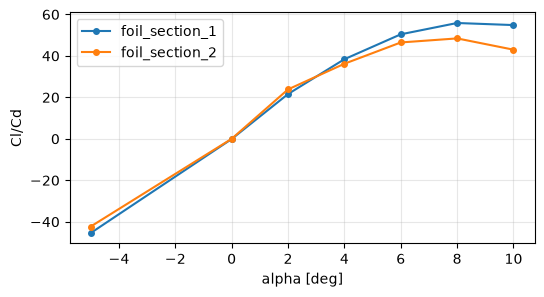

In [4]:
plt.figure(figsize=(6, 3))
for s in result["sections"]:
    d = s["data"]
    plt.plot(d["alpha"], d["Cl_Cd"], "o-", ms=4, label=s["section"])
plt.xlabel("alpha [deg]"); plt.ylabel("Cl/Cd"); plt.grid(alpha=0.3); plt.legend()
plt.show()

## Chordwise pressure distribution

`top_Cp`/`bot_Cp` carry one array per sweep point, paired with `top_x`/`bot_x`.

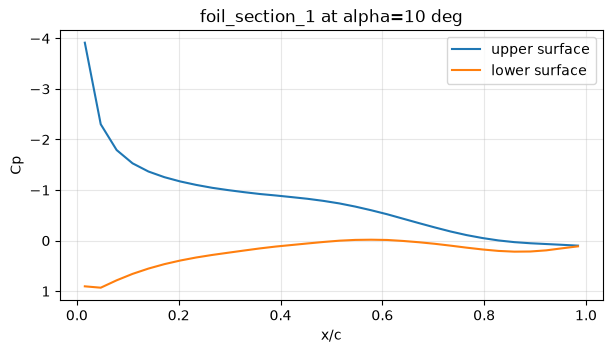

In [5]:
d = result["sections"][0]["data"]
i = len(d["alpha"]) - 1                        # last sweep point

plt.figure(figsize=(7, 3.5))
plt.plot(d["top_x"][i], d["top_Cp"][i], label="upper surface")
plt.plot(d["bot_x"][i], d["bot_Cp"][i], label="lower surface")
plt.gca().invert_yaxis()
plt.xlabel("x/c"); plt.ylabel("Cp"); plt.grid(alpha=0.3); plt.legend()
plt.title(f"{result['sections'][0]['section']} at alpha={d['alpha'][i]:.0f} deg")
plt.show()
client.close()